# IAD Pipeline — Training
Anomaly detection pipeline using FiftyOne, Weights & Biases, and the IAD framework.

This notebook uses the refactored `AnomalyDetectionManager`:
- `train()` / `eval()` no longer take a `tiling` flag or call `adjustPaths()` manually — tiled-ensemble is currently the only supported mode, and paths are resolved internally by `_prepareRun`.
- Before calling an action, we check `manager.can_run(...)` / `manager.get_missing_requirements(...)` so we can show the user *why* something isn't ready yet instead of hitting a bare exception.
- State-related failures raise `ManagerStateError` subclasses (`NoModelLoadedError`, `NoDatasetLoadedError`, `TilingNotConfiguredError`, `ModelNotTrainedError`, `CheckpointNotFoundError`), each carrying a `.missing` list.

## 1. Environment Setup
Configure database URI and API keys.

In [1]:
import os
import sys
import warnings

# Set BEFORE any fiftyone imports
os.environ["FIFTYONE_DATABASE_URI"] = "mongodb://localhost"
os.environ["WANDB_API_KEY"] = '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'

sys.path.append("src")

import wandb
import logging
from pathlib import Path

from src.manager import AnomalyDetectionManager as ADM
from src.manager import DatasetSession as DS
from src.manager import (
    # ManagerState,
    ManagerError,
    ManagerStateError,
    # ConfigError,
    # NoModelLoadedError,
    # NoDatasetLoadedError,
    # TilingNotConfiguredError,
    # ModelNotTrainedError,
    CheckpointNotFoundError,
)
from src.tiling.tilingCheckpoints import checkTiledCheckpointsExist


warnings.filterwarnings("ignore", category=FutureWarning, module="timm.models.layers")
warnings.filterwarnings("ignore", category=DeprecationWarning, module="openvino.runtime")

logger = logging.getLogger("logger")

wandb.login()

/Users/dapo/Documents/Code/IAD/.venv/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
wandb: Currently logged in as: daniel-pommer (daniel-pommer-technische-hochschule-n-rnberg-georg-simon-ohm) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 2. Configuration
Set your run parameters here before executing the pipeline.

`ADM.loadProduct(...)` loads the model, configures tiling, and resolves output/checkpoint
paths for you — no manual `adjustPaths()` call needed afterwards.

In [2]:
# from src.userConfigs import Product
from src.setup import Product

datasetDir  = Path("datasets/")
configDir   = Path("configs/")
outputPath  = Path("results/")
productPath = Path("Products/cable.yaml")
productConfigPath = Path(configDir / productPath)

product: Product
manager, product = ADM.loadProduct(
    productConfigPath=productConfigPath,
    outputPath=outputPath,
    configDir=configDir,
)

print(f"Loaded product: {product.name}")
print(product)
print(f"Manager state: {manager.state!r}")

Trying to find previous run under results for the InpFormer model and the cable product
Checking results/MVTecADShort/cable/InpFormer/tiled/runs/20260731-190136_f55da07a/manifest.yaml
Checkpoints complete!
Found metrics: {}
Wanted only complete tile checkpoints. Some checkpoints are missing ([PosixPath('results/MVTecADShort/cable/InpFormer/tiled/runs/20260731-190136_f55da07a/checkpoints/model0_0.ckpt'), PosixPath('results/MVTecADShort/cable/InpFormer/tiled/runs/20260731-190136_f55da07a/checkpoints/model0_1.ckpt'), PosixPath('results/MVTecADShort/cable/InpFormer/tiled/runs/20260731-190136_f55da07a/checkpoints/model1_0.ckpt'), PosixPath('results/MVTecADShort/cable/InpFormer/tiled/runs/20260731-190136_f55da07a/checkpoints/model1_1.ckpt')]). Skipping
Checking results/MVTecADShort/cable/InpFormer/tiled/runs/20260731-191344_33e5c71d/manifest.yaml
Checkpoints complete!
Found metrics: {}
Wanted only complete tile checkpoints. Some checkpoints are missing ([PosixPath('results/MVTecADShort/cable

/Users/dapo/Documents/Code/IAD/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'pre_processor' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['pre_processor'])`.
/Users/dapo/Documents/Code/IAD/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'post_processor' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['post_processor'])`.
/Users/dapo/Documents/Code/IAD/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'evaluator' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['evaluator'])`.


INFO: Loaded model: dinov2reg_vit_base_14
INFO: Successfully loaded model InpFormer: InpFormer(
  (pre_processor): PreProcessor(
    (transform): Compose(    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False))
    (export_transform): Compose(    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False))
  )
  (post_processor): AOIPostProcessor(
    (_image_threshold_metric): F1AdaptiveThreshold()
    (_pixel_threshold_metric): F1AdaptiveThreshold()
    (_image_min_max_metric): MinMax()
    (_pixel_min_max_metric): MinMax()
  )
  (evaluator): Evaluator(
    (val_metrics): ModuleList(
      (0): AUROC()
      (1): F1Score()
      (2): AUPR()
      (3): AUROC()
      (4): F1Score()
      (5): AUPR()
    )
    (test_metrics): ModuleList(
      (0): AUROC()
      (1): F1Score()
      (2): AUPR()
      (3): AUROC()
      (4): F1Score()
      (5): AUPR()
    )
  )
  (model): InpFormerModel(
    (encoder): DinoVisionTransformer(
      (patch_e

## 3. Load & Select Dataset

We load the dataset session and select the product's category. `DatasetSession` is
independent of the manager's readiness state — you can load and inspect data before
a model is ready, or vice versa.

In [3]:
datasetSession = DS.loadDatasetFromConfig(product.datasetConfig, overwrite=False, merge=False)
datasetSession.select_category(product.name)

print(f"Dataset: {datasetSession.datasetName}, category: {datasetSession.category}")
print(f"Images in view: {len(datasetSession.FO_Dataset)}")

INFO: Dataset 'MVTecADShort' already exists in database
INFO: Loading from database
INFO: Loaded dataset 'MVTecADShort' from database!
INFO: Selected category: cable, 374 images


ERROR: Dataset name 'MVTecADShort-cable' is not available


ERROR: Dataset name 'MVTecADShort-cable' is not available
INFO: Deleting MVTecADShort-cable from database and reloading.
Dataset: MVTecADShort, category: ['cable']
Images in view: 374


## 3.1 Inspect Dataset


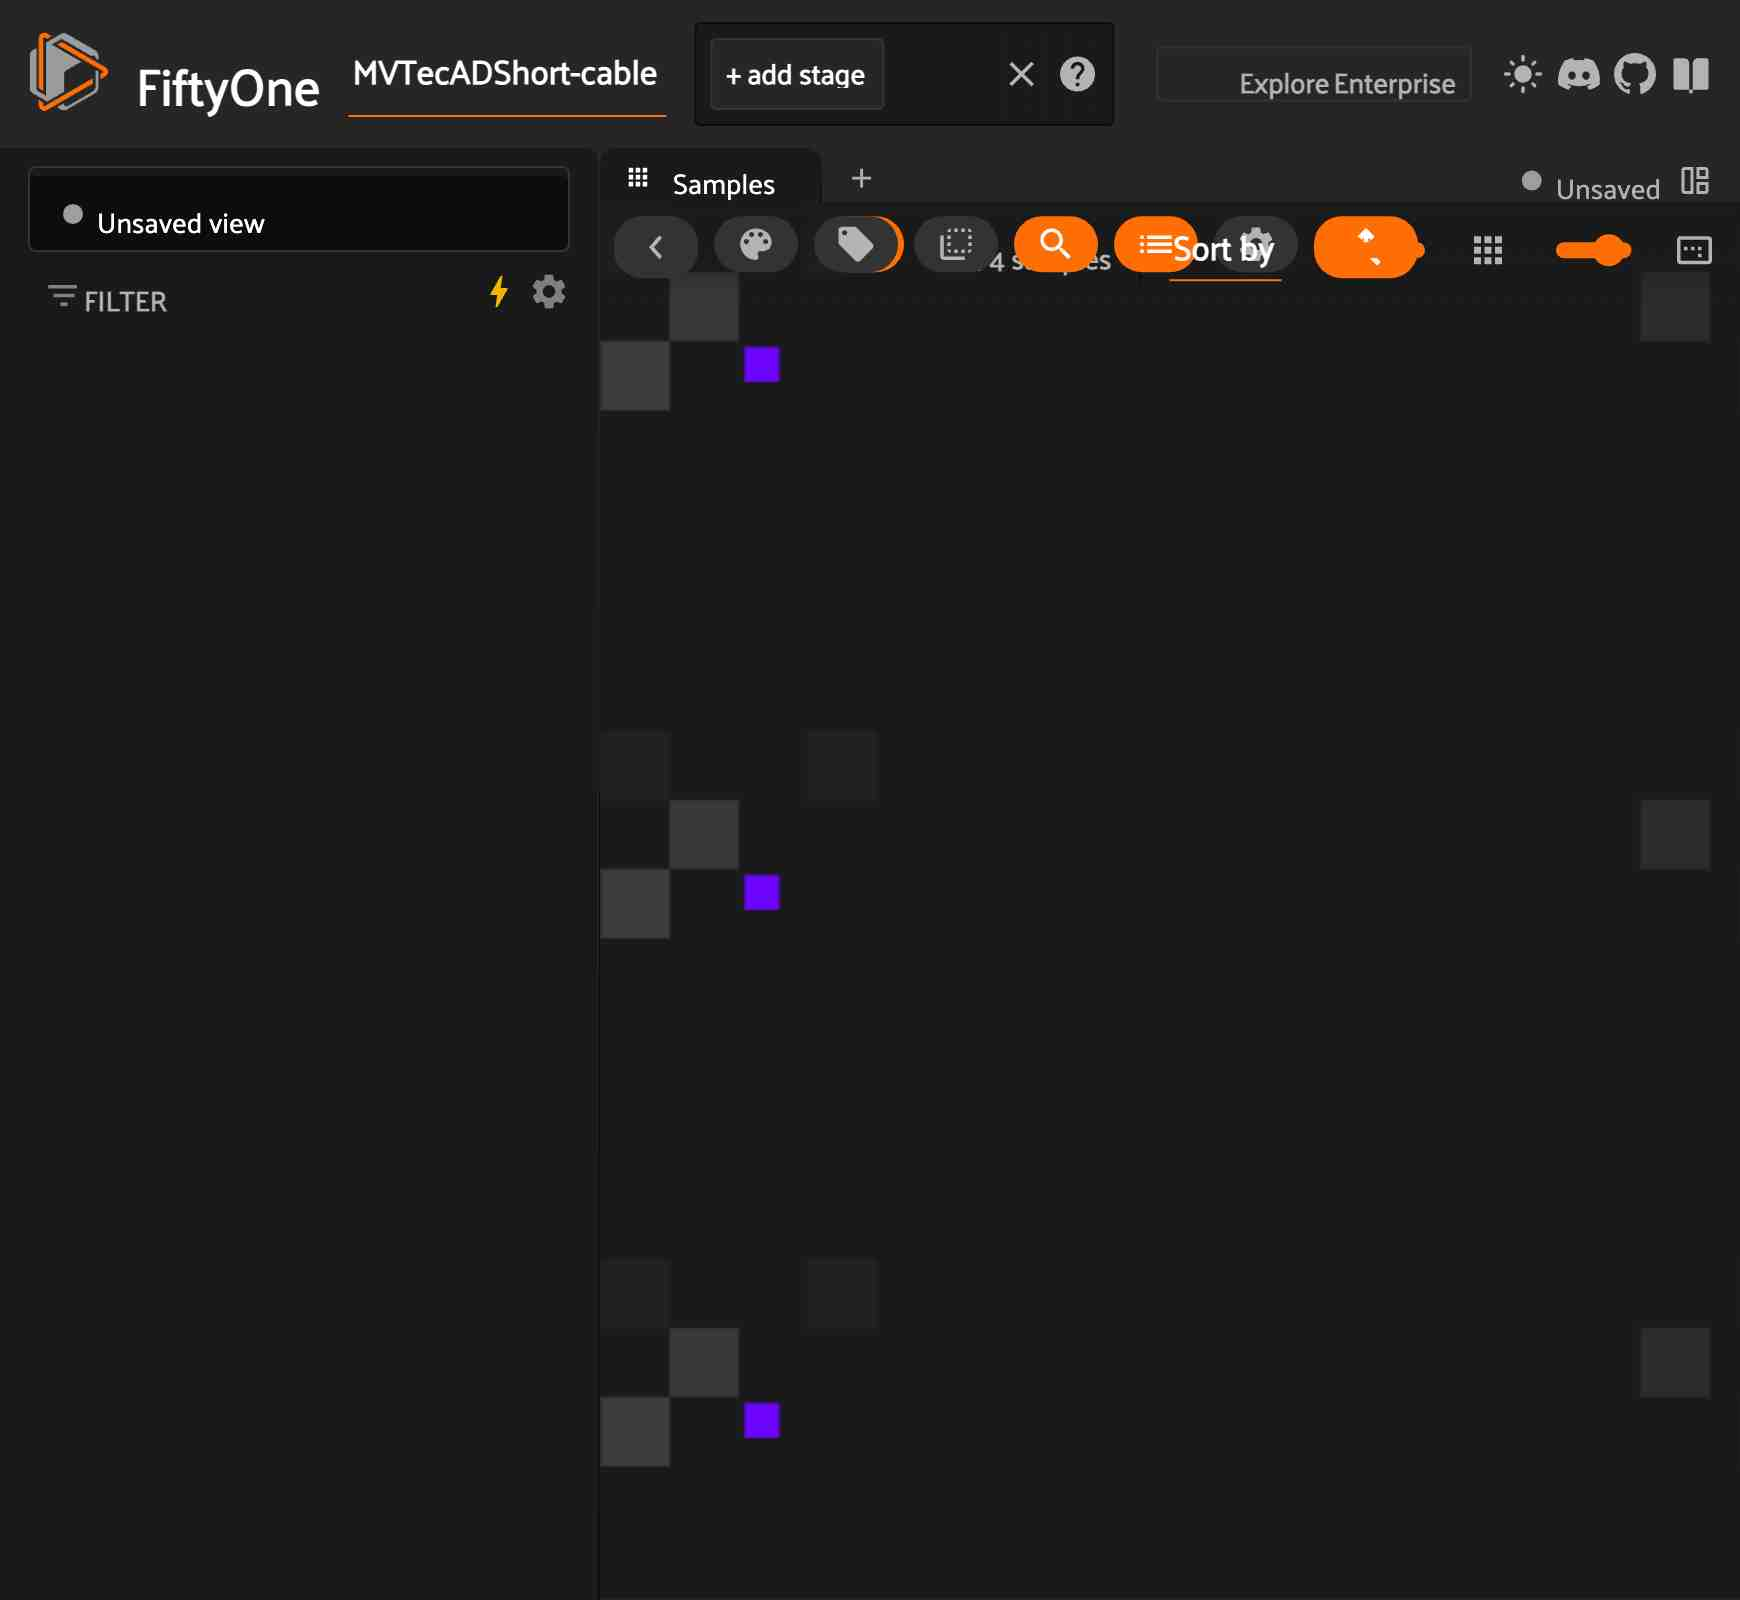

INFO: Session: localhost:5151


Dataset:          MVTecADShort-cable
Media type:       image
Num samples:      374
Selected samples: 0
Selected labels:  0
Session URL:      http://localhost:5151/

In [4]:
datasetSession.launchSession()

## 4. Readiness Check

Before training, ask the manager what (if anything) is missing, rather than firing the
call and translating an exception. This is the check a UI would run to enable/disable
a "Train" button.

In [5]:
manager.attachDatasetSession(datasetSession)
missing = manager.get_missing_requirements("train")
if missing:
    print("Not ready to train yet. Missing:")
    for item in missing:
        print(f"  - {item}")
else:
    print("Ready to train.")
# manager._prepareRun(trainerConfig=product.trainerConfig,
#     modelConfig=product.modelConfig,
#     datamoduleConfig=product.datamoduleConfig,
#     datasetSession=datasetSession,
#     tilingPipelineConfig=product.tilingPipelineConfig,)

INFO: Attached dataset 'MVTecADShort' (category=cable) to manager.
Ready to train.


## 5. Training

`train()` is tiled-ensemble only for now (the `tiling` parameter has been removed —
non-tiled support will be added later as an explicit branch, once implemented). Paths,
tiling setup, callbacks, and the W&B logger are all handled internally by `_prepareRun`.

We wrap the call so that a `ManagerStateError` (e.g. someone re-running this cell before
`generateModel`/`setupTiling` ran) produces a clear message instead of a raw traceback.

In [6]:
try:

    manager.train(
        trainerConfig=product.trainerConfig,
        modelConfig=product.modelConfig,
        datamoduleConfig=product.datamoduleConfig,
        datasetSession=datasetSession,
        tilingPipelineConfig=product.tilingPipelineConfig,
    )
    print("Training complete.")
except ManagerStateError as e:
    print(f"Could not train: {e}")
    print(f"Missing: {e.missing}")
except ManagerError as e:
    print(f"Training failed: {e}")

print(f"Manager state: {manager.state!r}")

INFO: Attached dataset 'MVTecADShort' (category=cable) to manager.
{'trainer': {'accelerator': 'mps', 'strategy': 'auto', 'devices': 'auto', 'num_nodes': 1, 'logger': {'class_path': 'anomalib.loggers.AnomalibWandbLogger', 'init_args': {'project': 'Glas 4.0', 'entity': 'daniel-pommer-technische-hochschule-n-rnberg-georg-simon-ohm', 'offline': False}}, 'callbacks': [{'__repr__': '<anomalib.callbacks.timer.TimerCallback object at 0x329436230>', '__class__': 'TimerCallback'}, {'__repr__': '<lightning.pytorch.callbacks.early_stopping.EarlyStopping object at 0x328c55f30>', '__class__': 'EarlyStopping'}, {'__repr__': '<lightning.pytorch.callbacks.model_checkpoint.ModelCheckpoint object at 0x33430f790>', '__class__': 'ModelCheckpoint'}], 'fast_dev_run': False, 'max_epochs': 10, 'max_steps': -1, 'overfit_batches': 0.0, 'check_val_every_n_epoch': 10, 'num_sanity_val_steps': 0, 'accumulate_grad_batches': 1, 'gradient_clip_val': 0, 'inference_mode': False, 'use_distributed_sampler': True, 'profile

Trainer: 0it [00:00, ?it/s]

INFO: Tiled ensemble training started. Separate models will be trained for 4 tile locations.
INFO: Initializing InpFormer model.


/Users/dapo/Documents/Code/IAD/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'pre_processor' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['pre_processor'])`.
/Users/dapo/Documents/Code/IAD/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'post_processor' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['post_processor'])`.
/Users/dapo/Documents/Code/IAD/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'evaluator' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['evaluator'])`.


INFO: Loaded model: dinov2reg_vit_base_14
INFO: Batch size probing skipped on accelerator 'mps'; using conservative default of 8.
INFO: Running <class 'tiling.tiled_ensemble.TrainModelJob'>
INFO: Training for tile at position (0, 0),


...

AOIPostProcessor on_validation_epoch_end

`Trainer.fit` stopped: `max_epochs=10` reached.


INFO: Training took 93.70 seconds


FIT Profiler Report

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|  Action                                                                                                                                                                     	|  Mean duration (s)	|  Num calls      	|  Total time (s) 	|  Percentage %   	|
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|  Total                                                                                                                                                                      

INFO: Job Trainer completed successfully.
Training complete.
Manager state: <ManagerState.CHECKPOINT_AVAILABLE|TRAINED|RUN_PREPARED|TILING_CONFIGURED|DATASET_LOADED|MODEL_LOADED: 63>


In [7]:
datasetSession.launchSession()
# datasetSession.save()

INFO: Session: localhost:5151


Dataset:          MVTecADShort-cable
Media type:       image
Num samples:      374
Selected samples: 0
Selected labels:  0
Session URL:      http://localhost:5151/

## 5.1 Training Loss Visualization

Each tile in the ensemble trains a separate model and logs to its own W&B run
(`AnomalibWandbLogger`, configured in `configs/Trainer/Training_InpFormer.yaml` via the
`logger:` key). The engine gives each tile a deterministic run id, grouped under this
ensemble run, and writes that id once to `manager.wandbManifestDir/model<i>_<j>.json` — we
just read those files back rather than re-deriving the id (see
`AOITiledEnsembleEngine._setup_anomalib_callbacks` in `src/tiling/ensemble_engine.py`, and
`src/run_paths.py` for the shared path/naming conventions manager.py and the engine both
draw from).

We pull each tile's full (unsampled) `train_loss_step` history via `wandb.Api()`, save it
raw to CSV next to the run, and plot it raw — no smoothing. Smoothing is better done
on-demand, either on the W&B dashboard (EMA slider) or from the saved CSVs.

This only works for training runs made **after** the W&B logger was wired up — older runs
under `results/` have no `wandb_runs/` directory.

Saved raw training loss plot to results/MVTecADShort/cable/InpFormer/tiled/runs/20260731-193542_d446a429/plots/train_loss.png


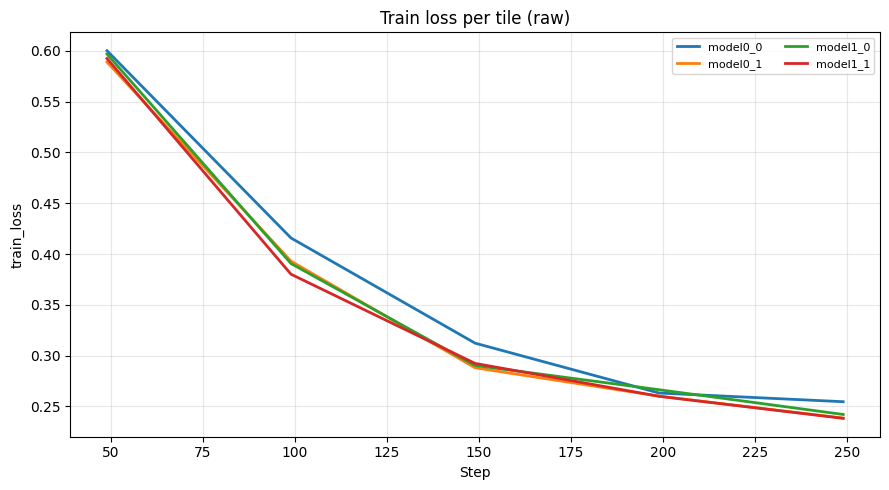

In [8]:
import json

import pandas as pd
import matplotlib.pyplot as plt

runDir = Path(manager.outputDir)
manifestDir = manager.wandbManifestDir  # single source of truth, see src/run_paths.py
plotsDir = runDir / "plots"

tileHistories = {}
if manifestDir.exists():
    plotsDir.mkdir(parents=True, exist_ok=True)
    api = wandb.Api()

    for manifestFile in sorted(manifestDir.glob("*.json")):
        entry = json.loads(manifestFile.read_text())
        tileName = manifestFile.stem
        runPath = f"{entry['entity']}/{entry['project']}/{entry['id']}"

        try:
            run = api.run(runPath)
        except Exception as e:
            print(f"Could not fetch {runPath}: {e}")
            continue

        # scan_history (not history()) returns every logged row, unsampled - history()
        # silently downsamples to ~500 points, which would smooth the curve implicitly.
        rows = list(run.scan_history(keys=["trainer/global_step", "train_loss_step"]))
        history = pd.DataFrame(rows).dropna(subset=["train_loss_step"])
        if history.empty:
            continue

        tileHistories[tileName] = history
        history.to_csv(plotsDir / f"train_loss_{tileName}.csv", index=False)
else:
    print(f"No W&B run manifest found under {manifestDir}.")
    print("This training run predates the W&B logger wiring, or hasn't been run yet.")

if not tileHistories:
    print("No W&B training history could be retrieved.")
else:
    fig, ax = plt.subplots(figsize=(9, 5))
    colors = plt.get_cmap("tab10")

    for i, (tileName, history) in enumerate(tileHistories.items()):
        ax.plot(
            history["trainer/global_step"], history["train_loss_step"],
            label=tileName, color=colors(i % 10), linewidth=2,
        )

    ax.set_title("Train loss per tile (raw)")
    ax.set_xlabel("Step")
    ax.set_ylabel("train_loss")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, ncol=2)
    fig.tight_layout()

    plotPath = plotsDir / "train_loss.png"
    fig.savefig(plotPath, dpi=150)
    print(f"Saved raw training loss plot to {plotPath}")
    plt.show()

## 6. Evaluation

`eval()` requires the model to actually be trained (`ManagerState.TRAINED`), which is
only set once `train()` confirms a checkpoint landed on disk — not just that the call
returned. Check readiness first, same pattern as training.

In [9]:
# ckptDir = Path("results/MVTecADShort/cable/Padim/tiled/checkpoints")
# ckptDir = manager.ckptDir
# if ckptDir is None:
#     raise ValueError
print(manager.modelTrainingDir)
print(manager.ckptDir)

if manager.modelTrainingDir is None and manager.ckptDir is not None:
    manager.modelTrainingDir = manager.ckptDir.parent
missing = manager.get_missing_requirements("eval")
print(missing)
# manager.loadCheckpoint(ckptDir, product.tilingPipelineConfig)

# if missing:
#     print("Not ready to evaluate yet. Missing:")
#     for item in missing:
#         print(f"  - {item}")

# if ManagerState.CHECKPOINT_AVAILABLE:
try:
    manager.eval(
        evalConfig=product.trainerConfig,
        modelConfig=product.modelConfig,
        datamoduleConfig=product.datamoduleConfig,
        datasetSession=datasetSession,
        tilingPipelineConfig=product.tilingPipelineConfig,
    )
    print("Evaluation complete.")
except ManagerStateError as e:
    print(f"Could not evaluate: {e}")
except ManagerError as e:
    print(f"Evaluation failed: {e}")

/Users/dapo/Documents/Code/IAD/results/MVTecADShort/cable/InpFormer/tiled/runs/20260731-185004_f0551d72
results/MVTecADShort/cable/InpFormer/tiled/runs/20260731-193542_d446a429/checkpoints
[]
INFO: Attached dataset 'MVTecADShort' (category=cable) to manager.
{'trainer': {'accelerator': 'mps', 'strategy': 'auto', 'devices': 'auto', 'num_nodes': 1, 'logger': {'class_path': 'anomalib.loggers.AnomalibWandbLogger', 'init_args': {'project': 'Glas 4.0', 'entity': 'daniel-pommer-technische-hochschule-n-rnberg-georg-simon-ohm', 'offline': False}}, 'callbacks': [{'__repr__': '<anomalib.callbacks.timer.TimerCallback object at 0x384e882b0>', '__class__': 'TimerCallback'}, {'__repr__': '<lightning.pytorch.callbacks.early_stopping.EarlyStopping object at 0x384e8a860>', '__class__': 'EarlyStopping'}, {'__repr__': '<lightning.pytorch.callbacks.model_checkpoint.ModelCheckpoint object at 0x384e88f40>', '__class__': 'ModelCheckpoint'}], 'fast_dev_run': False, 'max_epochs': 10, 'max_steps': -1, 'overfit_b

Predict: 0it [00:00, ?it/s]

INFO: Tiled ensemble predicting started using Using ckpt_pathval data.
INFO: Initializing InpFormer model.


/Users/dapo/Documents/Code/IAD/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'pre_processor' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['pre_processor'])`.
/Users/dapo/Documents/Code/IAD/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'post_processor' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['post_processor'])`.
/Users/dapo/Documents/Code/IAD/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'evaluator' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['evaluator'])`.


INFO: Loaded model: dinov2reg_vit_base_14
INFO: Loading checkpoint from ckpt_path: /Users/dapo/Documents/Code/IAD/results/MVTecADShort/cable/InpFormer/tiled/runs/20260731-185004_f0551d72/checkpoints/model0_0.ckpt. No Model from previous training job available.
INFO: Creating a dataloader from a datamodule. Usually the case during the validation or test step.
INFO: Batch size probing skipped on accelerator 'mps'; using conservative default of 8.
Using validation data
INFO: Start of predicting for tile at position (0, 0),


...

INFO: Job VisualizeOnDisk completed successfully.
INFO: Running job 51Visualize



51Visualize: 0it [00:00, ?it/s]

INFO: Starting visualisation for Fiftyone.


51 Visualisation: 100%|██████████| 10/10 [00:00<00:00, 10.02it/s]
51Visualize: 1it [00:01,  1.00s/it]

INFO: Job 51Visualize completed successfully.
Evaluation complete.


In [10]:
datasetSession.launchSession()

INFO: Session: localhost:5151


Dataset:          MVTecADShort-cable
Media type:       image
Num samples:      374
Selected samples: 0
Selected labels:  0
Session URL:      http://localhost:5151/

## 6.1 Anomaly Score Distribution & Threshold

`eval()` writes the post-processing statistics (image/pixel threshold, min/max used for
normalization) to `stats.json` in the run directory, and writes each sample's raw
anomaly score into the FiftyOne dataset as `pred_anomaly_score_<model_name>` (see
`AOIStatisticsJob` / `AOIFiftyOneVisJob` in `src/tiling/jobs.py`). Neither is kept on
`manager` in memory, so we read both back here: the threshold from disk, the per-image
scores from the dataset.

Loaded stats from /Users/dapo/Documents/Code/IAD/results/MVTecADShort/cable/InpFormer/tiled/runs/20260731-185004_f0551d72/stats.json
Image threshold: 0.2554


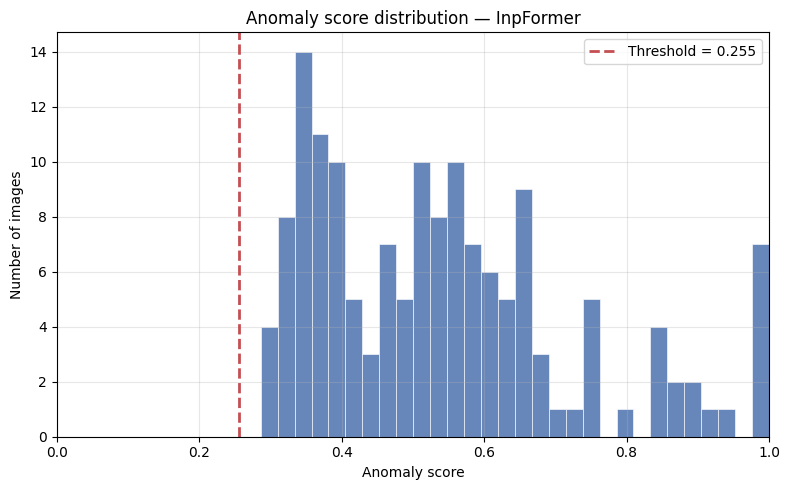

In [11]:
import json
import numpy as np
import matplotlib.pyplot as plt

modelName = product.modelConfig.name
scoreField = f"pred_anomaly_score_{modelName}"

runDir = Path(manager.modelTrainingDir) if manager.modelTrainingDir is not None else Path(manager.outputDir)
statsCandidates = [runDir / "stats.json", runDir / "checkpoints" / "stats.json"]
statsPath = next((p for p in statsCandidates if p.exists()), None)

if statsPath is None:
    print(f"No stats.json found under {runDir}. Checked: {[str(p) for p in statsCandidates]}")
    print("Run eval() first.")
else:
    with statsPath.open() as f:
        stats = json.load(f)
    imageThreshold = stats["image_threshold"]
    print(f"Loaded stats from {statsPath}")
    print(f"Image threshold: {imageThreshold:.4f}")

    predictedView = datasetSession.FO_Dataset.match_tags("predicted")
    scores = [s[scoreField] for s in predictedView.select_fields(scoreField) if s[scoreField] is not None]

    if not scores:
        print(f"No samples with field '{scoreField}' found - run eval() to populate anomaly scores.")
    else:
        scores = np.array(scores)
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.hist(scores, bins=30, color="#4C72B0", alpha=0.85, edgecolor="white", linewidth=0.5)
        ax.axvline(
            imageThreshold, color="#C44E52", linewidth=2, linestyle="--",
            label=f"Threshold = {imageThreshold:.3f}",
        )
        ax.set_xlabel("Anomaly score")
        ax.set_ylabel("Number of images")
        ax.set_title(f"Anomaly score distribution — {modelName}")
        ax.set_xlim(0.0,1.0)
        ax.grid(alpha=0.3)
        ax.legend()
        fig.tight_layout()
        plt.show()

## 7. Evaluate on Unknown / Prediction Data

Inference reads its checkpoint from an explicit `trainingDir` (which may belong to a
different manager/session than the one currently in memory) rather than relying on
`self.ckptDir` from the last training run. `inference()` checks that the checkpoint
file actually exists at that path and raises `CheckpointNotFoundError` if not — state
flags alone can't guarantee this, since `trainingDir` is caller-supplied.

This cell is left commented out, matching the placeholder in the original notebook — 
uncomment and adjust `predDatasetName` / `predDatasetDir` to run a prediction pass.

In [12]:
predDatasetName = "MVTecADShortPred"
predDatasetDir = datasetDir / predDatasetName

from src.setup import DataModuleConfig

predSession = DS.loadDatasetFromDisk(
    predDatasetDir,
    datasetName=predDatasetName,
    overwrite=False,
    merge=False,
    split=("pred",),
)
predSession.select_category(product.name)

manager.modelTrainingDir = product.refresh_training_dir(manager.baseOutputDir)

missing = manager.get_missing_requirements("inference")
if missing:
    print("Not ready for inference yet. Missing:")
    for item in missing:
        print(f"  - {item}")
else:
    try:
        manager.inference(
            inferencerConfig=product.inferencerConfig,
            modelConfig=product.modelConfig,
            modelTrainingDir=product.modelTrainingDir,
            datamoduleConfig=DataModuleConfig.load_datamodule_config_from_yaml(product.inferencerConfigPath),
            datasetSession=predSession,
            tilingPipelineConfig=product.tilingPipelineConfig,
        )
        print("Inference complete.")
    except CheckpointNotFoundError as e:
        print(f"No checkpoint available: {e}")
    except ManagerStateError as e:
        print(f"Could not run inference: {e}")
    except ManagerError as e:
        print(f"Inference failed: {e}")

predSession.launchSession()

ERROR: Dataset name 'MVTecADShortPred' is not available


ERROR: Dataset name 'MVTecADShortPred' is not available
INFO: There are 20 images in the MVTecADShortPred dataset.
INFO: There are 1 categorie(s) in the MVTecADShortPred dataset.
INFO: ['cable']
INFO: Selected category: cable, 20 images


ERROR: Dataset name 'MVTecADShortPred-cable' is not available


ERROR: Dataset name 'MVTecADShortPred-cable' is not available
INFO: Deleting MVTecADShortPred-cable from database and reloading.
Trying to find previous run under results for the InpFormer model and the cable product
Checking results/MVTecADShort/cable/InpFormer/tiled/runs/20260731-190136_f55da07a/manifest.yaml
Checkpoints complete!
Found metrics: {}
Wanted only complete tile checkpoints. Some checkpoints are missing ([PosixPath('results/MVTecADShort/cable/InpFormer/tiled/runs/20260731-190136_f55da07a/checkpoints/model0_0.ckpt'), PosixPath('results/MVTecADShort/cable/InpFormer/tiled/runs/20260731-190136_f55da07a/checkpoints/model0_1.ckpt'), PosixPath('results/MVTecADShort/cable/InpFormer/tiled/runs/20260731-190136_f55da07a/checkpoints/model1_0.ckpt'), PosixPath('results/MVTecADShort/cable/InpFormer/tiled/runs/20260731-190136_f55da07a/checkpoints/model1_1.ckpt')]). Skipping
Checking results/MVTecADShort/cable/InpFormer/tiled/runs/20260731-191344_33e5c71d/manifest.yaml
Checkpoints comple

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:24                                                                                   │
│                                                                                                  │
│   21 │   │   print(f"  - {item}")                                                                │
│   22 else:                                                                                       │
│   23 │   try:                                                                                    │
│ ❱ 24 │   │   manager.inference(                                                                  │
│   25 │   │   │   inferencerConfig=product.inferencerConfig,                                      │
│   26 │   │   │   modelConfig=product.modelConfig,                                                │
│   27 │   │   │   modelTrainingDir=product.modelTrainingDir,                                      │
│                                                                                                  │
│ /Users/dapo/Documents/Code/IAD/src/manager.py:904 in inference                                   │
│                                                                                                  │
│   901 │   │   # self._apply_visualizer_output_dir(ctx.outputDir)                                 │
│   902 │   │   # self.setupTiling(tilingPipelineConfig)                                           │
│   903 │   │                                                                                      │
│ ❱ 904 │   │   self._inferenceTiledModel(                                                         │
│   905 │   │   │   trainingDir=modelTrainingDir,                                                  │
│   906 │   │   │   ckptDir=self.ckptDir,                                                          │
│   907 │   │   │   datasetSession=datasetSession,                                                 │
│                                                                                                  │
│ /Users/dapo/Documents/Code/IAD/src/manager.py:762 in _inferenceTiledModel                        │
│                                                                                                  │
│   759 │   │   │   │   │   │   │   │   │   │     modelConfig=modelConfig                          │
│   760 │   │   │   │   │   │   │   │   │   │     )                                                │
│   761 │   │                                                                                      │
│ ❱ 762 │   │   _run_in_large_stack(inferencerPipeline.run)                                        │
│   763 │                                                                                          │
│   764 │   def _prepareRun(                                                                       │
│   765 │   │   self,                                                                              │
│                                                                                                  │
│ /Users/dapo/Documents/Code/IAD/src/manager.py:76 in _run_in_large_stack                          │
│                                                                                                  │
│    73 │   │   threading.stack_size(prev)                                                         │
│    74 │                                                                                          │
│    75 │   if exc:                                                                                │
│ ❱  76 │   │   raise exc[0]                                                                       │
│    77                                                                                            │
│    78 os.environ["TRUST_REMOTE_CODE"] = "1"                                                      │
│    79 warnings.filterwarnings("ignore", category=FutureWarn